In [ ]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import twistaly as tw

parent_dir = "data/"
file_dir = "data100ns-2008"
output_dir = "output-100ns2008"

u_mean = md.Universe(parent_dir + file_dir + "/md_1.tpr", parent_dir + output_dir + "/md_1_mean.xtc")
chains = u_mean.select_atoms("protein").fragments

In [3]:
group = "backbone"
mol = 0
molecule = chains[3*mol:3*mol + 3]
molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group)+ molecule[2].select_atoms(group)).positions

len_mol = (molecule_coords[:,2].max() - molecule_coords[:,2].min()) / 10

molecule_mean_filt = tw.remove_ends(0.5, molecule_coords) / 10

# Cylindrical Coordinates
rad_mol, phi_mol, z_mol = tw.cyl_proj(molecule_mean_filt)
#rad_mol, phi_mol, z_mol = ct.cyl_proj(molecule_coords)

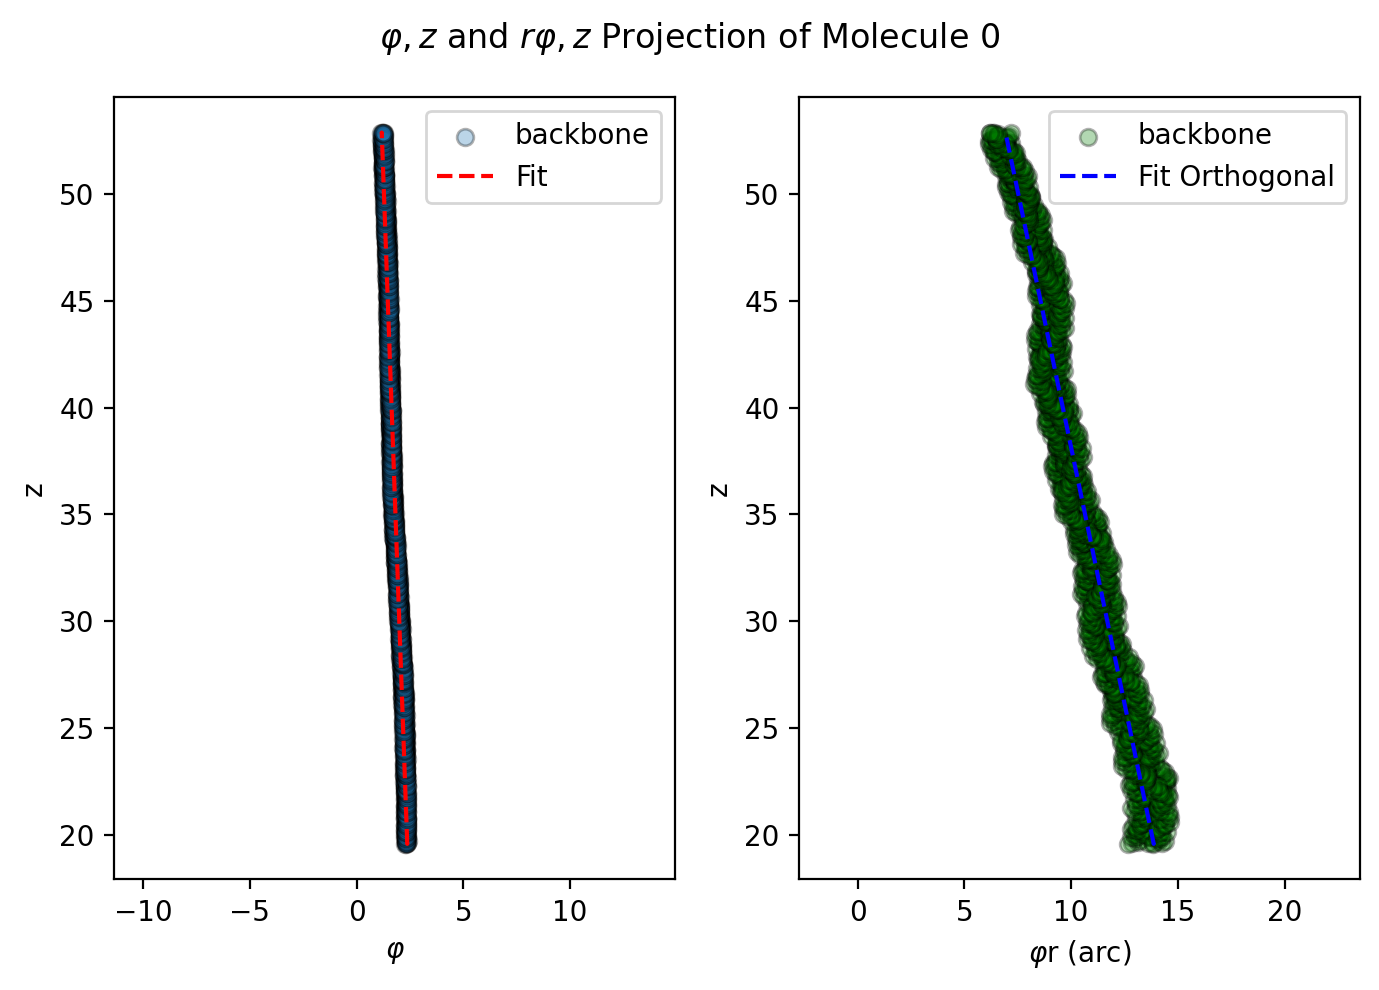

In [4]:
arc_mol = rad_mol*phi_mol

fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=200)

ax[0].scatter(phi_mol, z_mol, alpha=0.3, edgecolor='k', label=group)
b, m = np.polynomial.polynomial.polyfit(z_mol, phi_mol, 1)
fit = np.polynomial.polynomial.Polynomial((b, m))  
ax[0].plot(fit(z_mol), z_mol, linestyle='dashed', color='r', label='Fit')

ax[0].axis('equal')
ax[0].set_xlabel(r'$\varphi$')
ax[0].set_ylabel(r'z')
ax[0].legend()

ax[1].scatter(arc_mol, z_mol, color='g', alpha=0.3, edgecolor='k', label=group)
# --- Orthogonal Regression ---
m, b, _ = tw.ortreglinfit(z_mol, arc_mol)
ax[1].plot(m*z_mol + b, z_mol, linestyle='dashed', color='b', label='Fit Orthogonal')

ax[1].axis('equal')
ax[1].set_xlabel(r'$\varphi$r (arc)')
ax[1].set_ylabel(r'z')
ax[1].legend()

plt.suptitle(rf'$\varphi, z$ and $r\varphi, z$ Projection of Molecule {mol}')
plt.tight_layout()
plt.show()

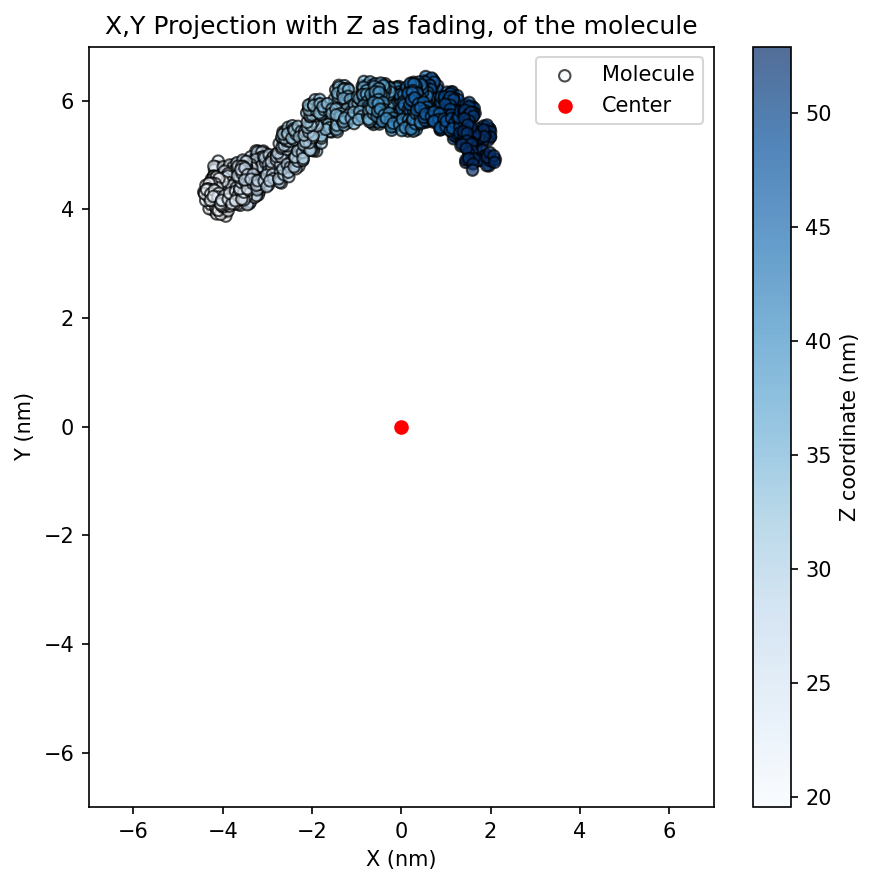

In [5]:
# Top proyection
xm, ym, zm = molecule_mean_filt[:, 0], molecule_mean_filt[:, 1], molecule_mean_filt[:, 2]

plt.figure(figsize=(6,6), dpi=150)
sc = plt.scatter(xm, ym, c=zm, cmap='Blues', s=30, alpha=0.7, edgecolor='k', label='Molecule')
plt.scatter([0], [0], color='r', label='Center')

cbar = plt.colorbar(sc)
cbar.set_label("Z coordinate (nm)")

plt.xlabel("X (nm)")
plt.ylabel("Y (nm)")
plt.title("X,Y Projection with Z as fading, of the molecule")

plt.xlim((-7, 7))
plt.ylim((-7, 7))
plt.tight_layout()
plt.legend()
plt.show()